# Off Center Propagation

Input doesn't come in exactly symmetric, so we get some even and odd mode activity in symmetric guide.

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from slab import SlabExact
from scipy.integrate import quad
from scipy.optimize import newton

plt.style.use('dark_background')
%matplotlib widget

In [88]:
A = SlabExact(symmetric=True, ns=[1, 1.44, 1], Ts=[8,2,8], wl=3.1e-06)

In [89]:
b = 1
shift = -.5

Lx = shift - b
Rx = shift + b

def quadratic_piecewise(x):
    conds = [((x-shift)<-b), ((-b<=(x-shift))*((x-shift)<=b)), ((x-shift)>b)]
    funcs = [0, lambda x: 1 - ((x - shift) / b) ** 2, 0]
    return np.piecewise(x, conds, funcs)

f0 = quadratic_piecewise

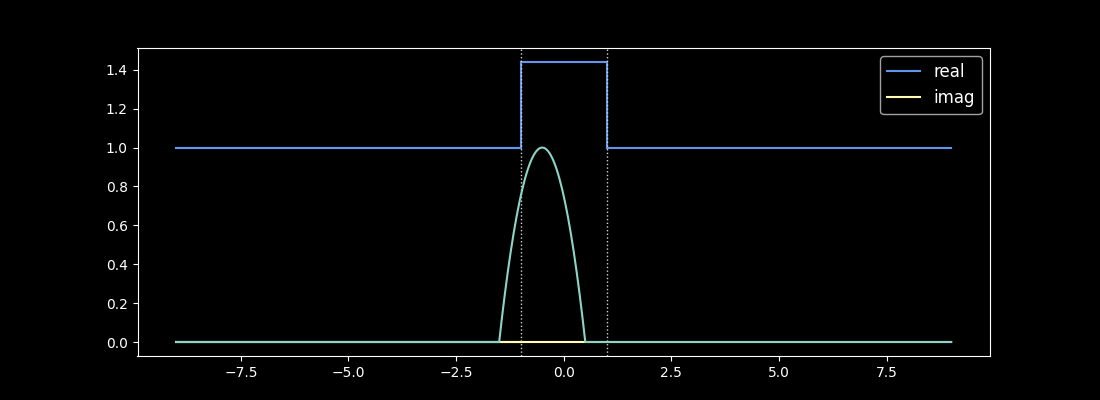

In [90]:
A.plot_refractive_index()
A.add_1d_plot(f0)

## Guided Portion

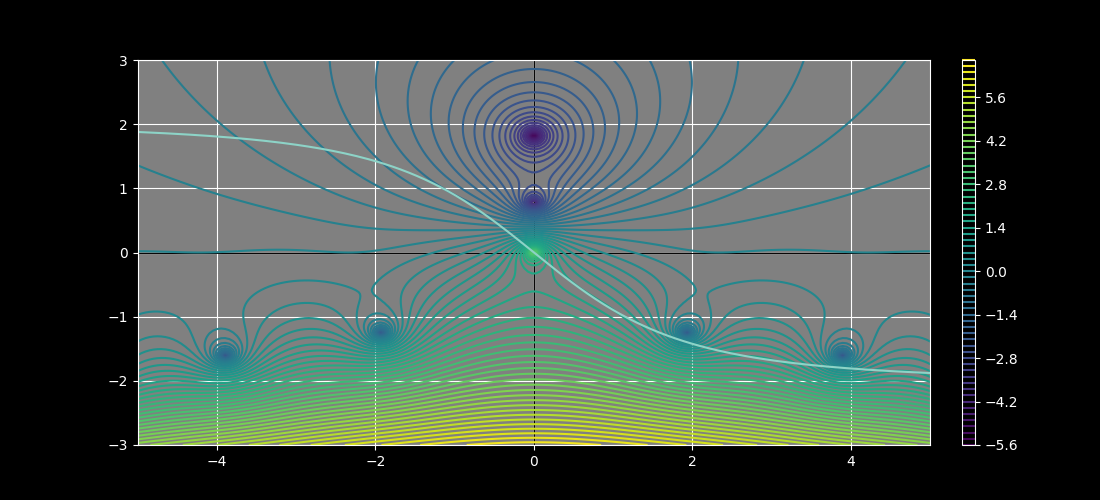

In [91]:
A.determinant_plot(-5, 5, -3, 3);

Get the guided mode propagagtion constants:

In [92]:
Zgo = newton(A.determinant, np.array(.5j))
Zge = newton(A.determinant, np.array(1.95j))

A.plot_points([Zgo, Zge])

In [93]:
Fge = A.fields(Zge)
Fgo = A.fields(Zgo)

In [94]:
alpha_odd = (quad(lambda x: f0(x) * Fgo(x), Lx, Rx, complex_func=True)[0]) / (quad(lambda x: Fgo(x) * Fgo(x), -8,8, complex_func=True)[0])
alpha_even = (quad(lambda x: f0(x) * Fge(x), Lx, Rx, complex_func=True)[0]) / (quad(lambda x: Fge(x) * Fge(x), -8, 8, complex_func=True)[0])

In [95]:
Guided = lambda x,z: alpha_odd * Fgo(x, z) + alpha_even * Fge(x, z)

(<Figure size 1200x500 with 1 Axes>, <Axes: >)

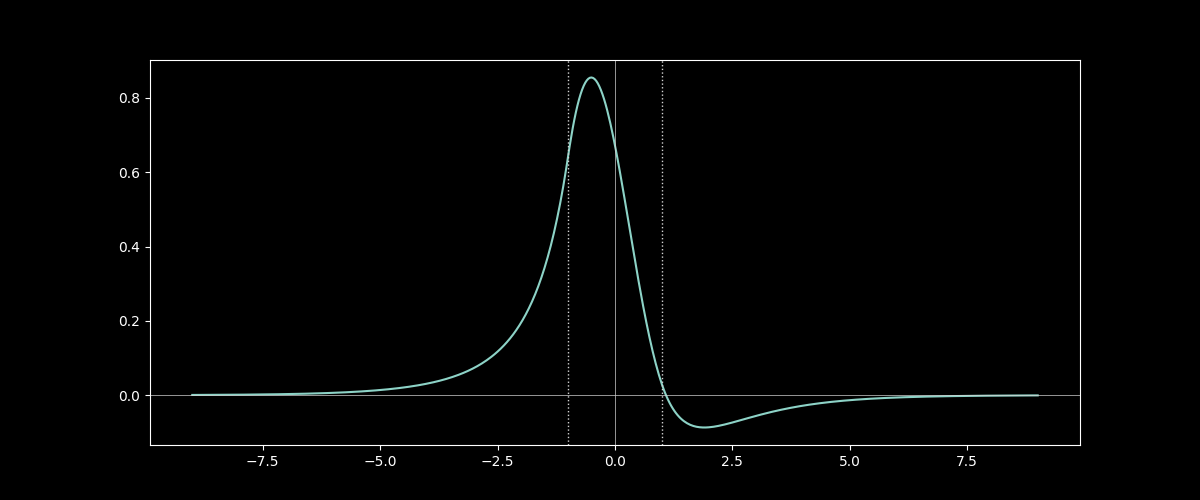

In [97]:
A.plot_field_1d(Guided)

## Radiation Portion

In [98]:
Propagator = A.propagator()
method = 'ours'
Normalizer = A.normalizer(method=method)

In [99]:
contour = A.real_contour(.000001, A.Z_evanescent.real, 260)
Pe1 = Propagator(contour, f0=f0, Lx=Lx, Rx=Rx, Normalizer=Normalizer, sign=1)
Po1 = Propagator(contour, f0=f0, Lx=Lx, Rx=Rx, Normalizer=Normalizer, sign=-1)

(<Figure size 1100x400 with 1 Axes>, <Axes: >)

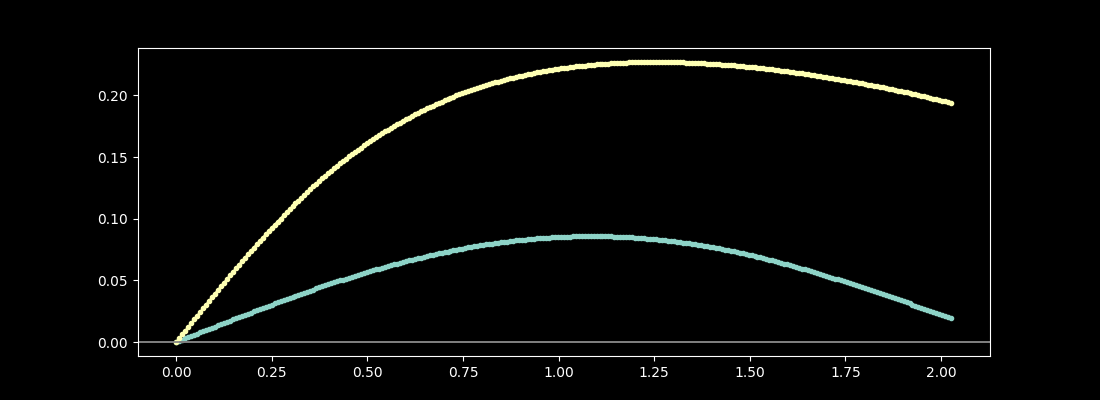

In [100]:
Pe1.plot_transform()
Po1.plot_transform(ax=plt.gca())

In [101]:
contour = A.real_contour(A.Z_evanescent.real, 7, 260)
Pe2 = Propagator(contour, f0=f0, Lx=Lx, Rx=Rx, Normalizer=Normalizer, sign=1)
Po2 = Propagator(contour, f0=f0, Lx=Lx, Rx=Rx, Normalizer=Normalizer, sign=-1)

(<Figure size 1100x400 with 1 Axes>, <Axes: >)

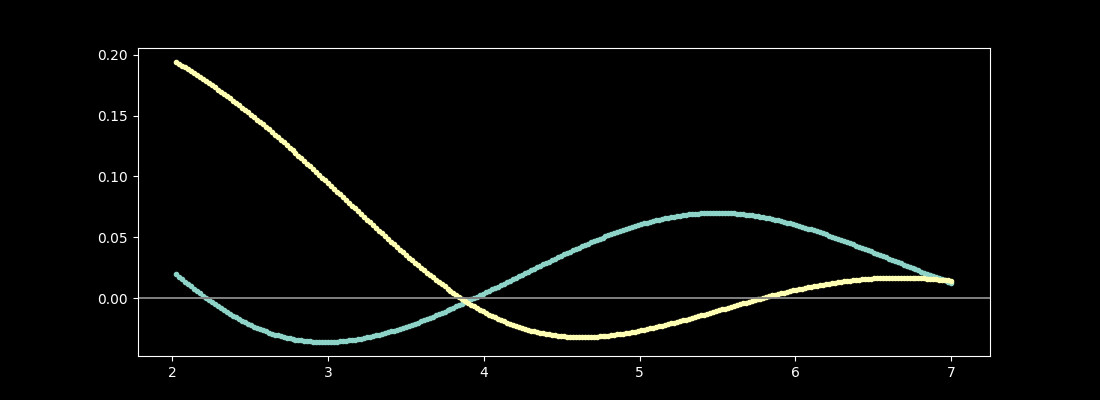

In [102]:
Pe2.plot_transform()
Po2.plot_transform(ax=plt.gca())

In [103]:
contour = A.real_contour(7, 30, 1000)
Pe3 = Propagator(contour, f0=f0, Lx=Lx, Rx=Rx, Normalizer=Normalizer, sign=1)
Po3 = Propagator(contour, f0=f0, Lx=Lx, Rx=Rx, Normalizer=Normalizer, sign=-1)

(<Figure size 1100x400 with 1 Axes>, <Axes: >)

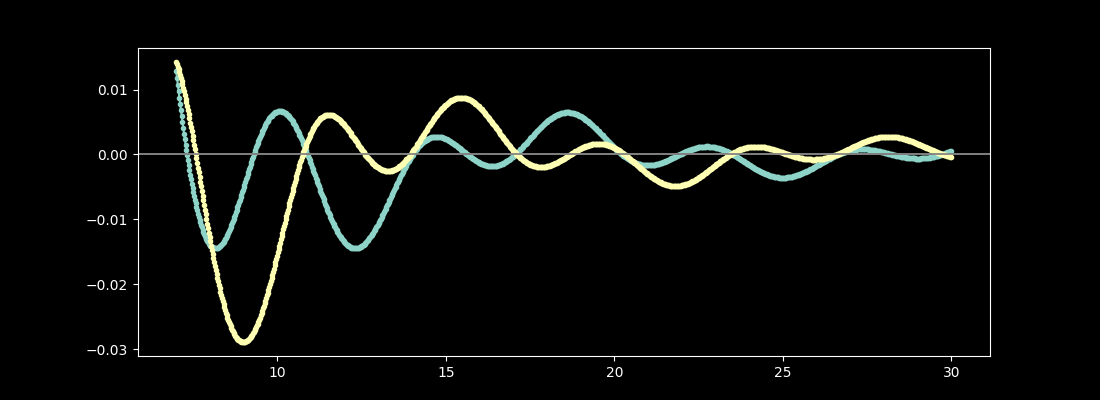

In [104]:
Pe3.plot_transform()
Po3.plot_transform(ax=plt.gca())

In [105]:
P_props = [
    Pe1,
    Po1,
]

P_evs = [
    Pe2,
    Po2,
    Pe3,
    Po3,
]

In [106]:
Prop = lambda x, z: sum([P.propagate(x, z) for P in P_props])
Ev = lambda x, z: sum([P.propagate(x, z) for P in P_evs])
Rad = lambda x, z: Prop(x,z) + Ev(x,z)
Full = lambda x, z: Rad(x,z) + Guided(x,z)

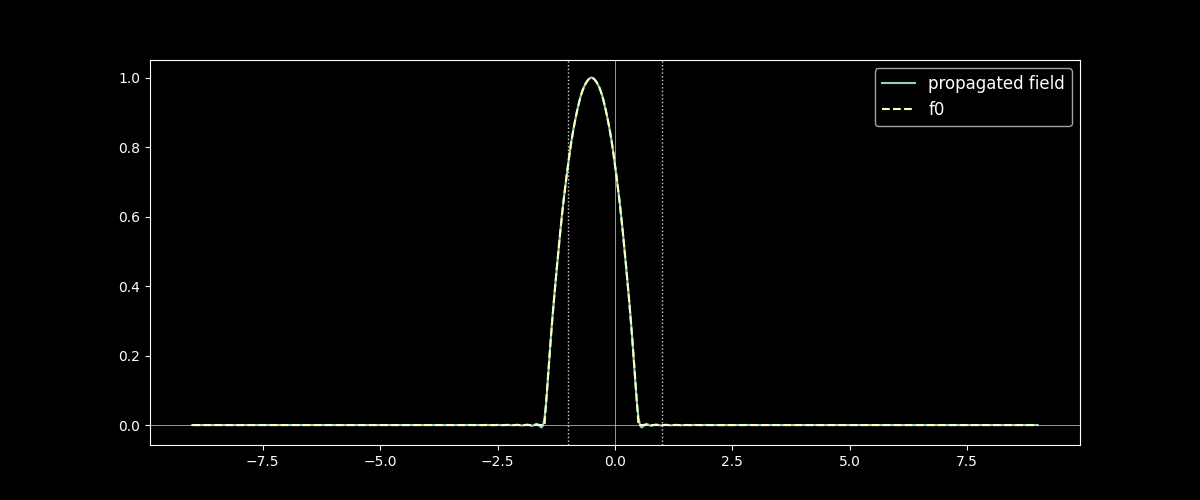

In [107]:
A.plot_field_1d(Full, label='propagated field')
A.add_1d_plot(f0, linestyle='--', label='f0')

(<Figure size 900x787.5 with 2 Axes>, <Axes: >)

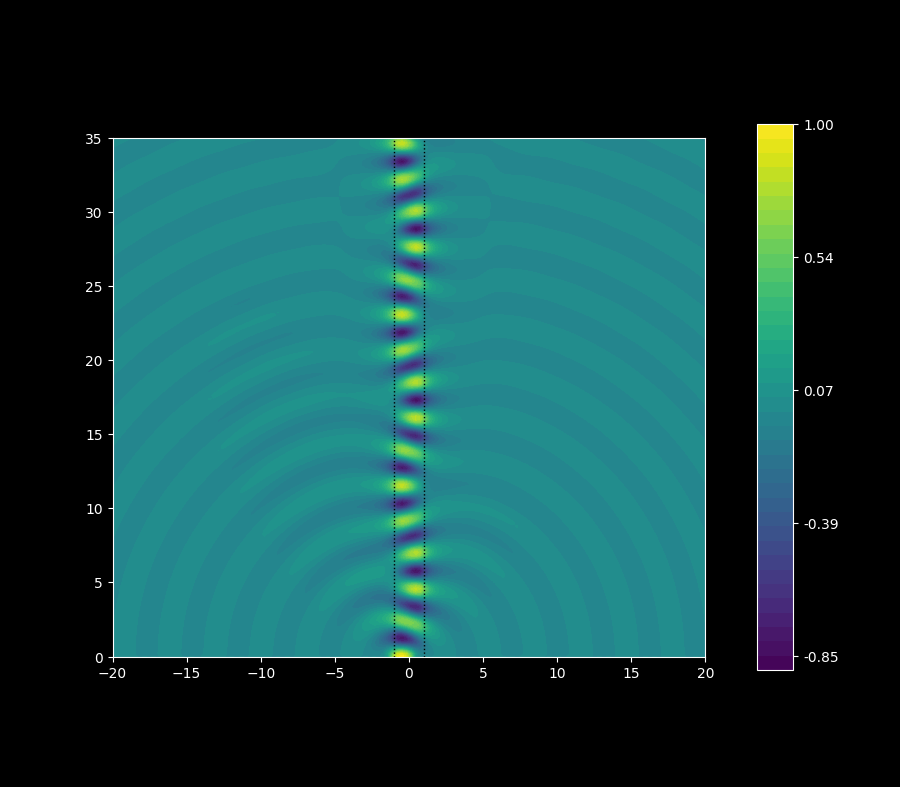

In [108]:
A.plot_field_2d(Full, zmax=35, zref=200, xs=np.linspace(-20,20,130))

(<Figure size 1000x500 with 1 Axes>, <Axes3D: >)

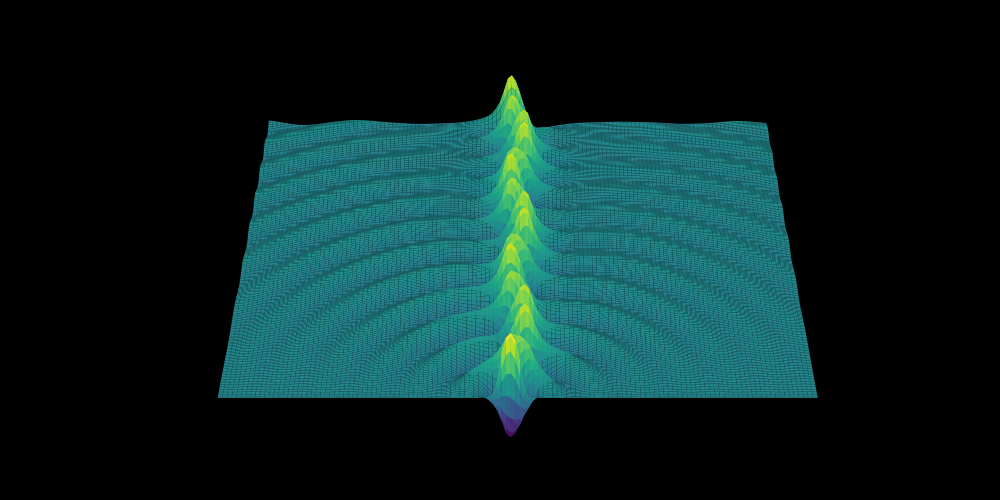

In [36]:
A.plot_field_2d_surface(Full, zmax=35, zref=200, xs=np.linspace(-20,20,130), cstride=1, rstride=1, elev=35)